<a href="https://colab.research.google.com/github/mahdi862/AI-parasite-detection/blob/main/CNN_model/Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.3.1 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import pathlib
import tensorflow as tf
import tensorflow_addons as tfa


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
    print("Running on TPU ", tpu.cluster_spec().as_dict()["worker"])
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    print("Not connected to a TPU runtime. Using CPU/GPU strategy")
    strategy = tf.distribute.MirroredStrategy()

Not connected to a TPU runtime. Using CPU/GPU strategy
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
model = EfficientNetB0(weights='imagenet')


In [ ]:
model = EfficientNetB0(include_top=False, weights='imagenet')


In [ ]:
IMG_SIZE = 256

In [ ]:
data_dir = '/content/gdrive/MyDrive/HealthAI/Colabs/Baseline'
data_dir = pathlib.Path(data_dir)

**Adding Padding to images**

In [ ]:
from PIL import Image
import os, sys

path = '/content/gdrive/MyDrive/HealthAI/Colabs/Baseline/S.Mansoni'
path_padded = '/content/gdrive/MyDrive/HealthAI/Colabs/Baseline_Padded/S.Mansoni'
dirs = os.listdir( path )
final_size = IMG_SIZE;

def resize_aspect_fit():
    for item in dirs:
         if item == '.DS_Store':
             continue
         if os.path.isfile(path + '/' + item):
             im = Image.open(path + '/' + item)
             f, e = os.path.splitext(path_padded+item)
             size = im.size
             ratio = float(final_size) / max(size)
             new_image_size = tuple([int(x*ratio) for x in size])
             im = im.resize(new_image_size, Image.ANTIALIAS)
             new_im = Image.new("RGB", (final_size, final_size))
             new_im.paste(im, ((final_size-new_image_size[0])//2, (final_size-new_image_size[1])//2))
             new_im.save(f + 'resized.jpg', 'JPEG', quality=120)
resize_aspect_fit()

In [ ]:
image_count = len(list(data_dir.glob('*/*')))
print(image_count)

197


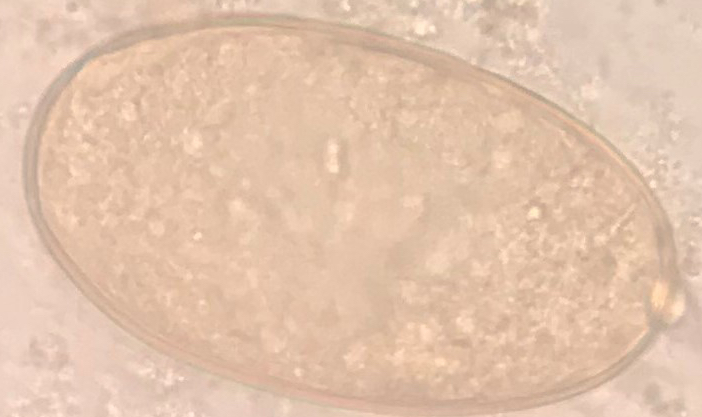

In [ ]:
fasciola = list(data_dir.glob('Fasciola/*'))
PIL.Image.open(str(fasciola[0]))

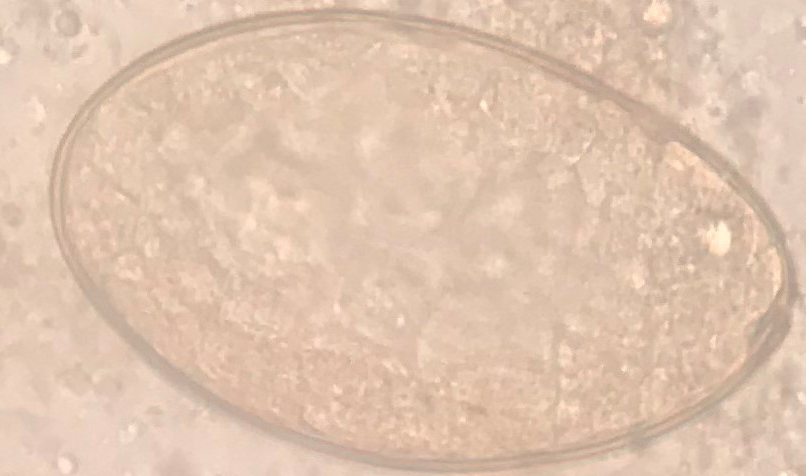

In [ ]:
PIL.Image.open(str(fasciola[1]))

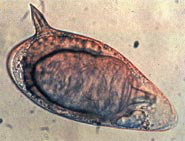

In [ ]:
s_mansoni = list(data_dir.glob('S.Mansoni/*'))
PIL.Image.open(str(s_mansoni[0]))

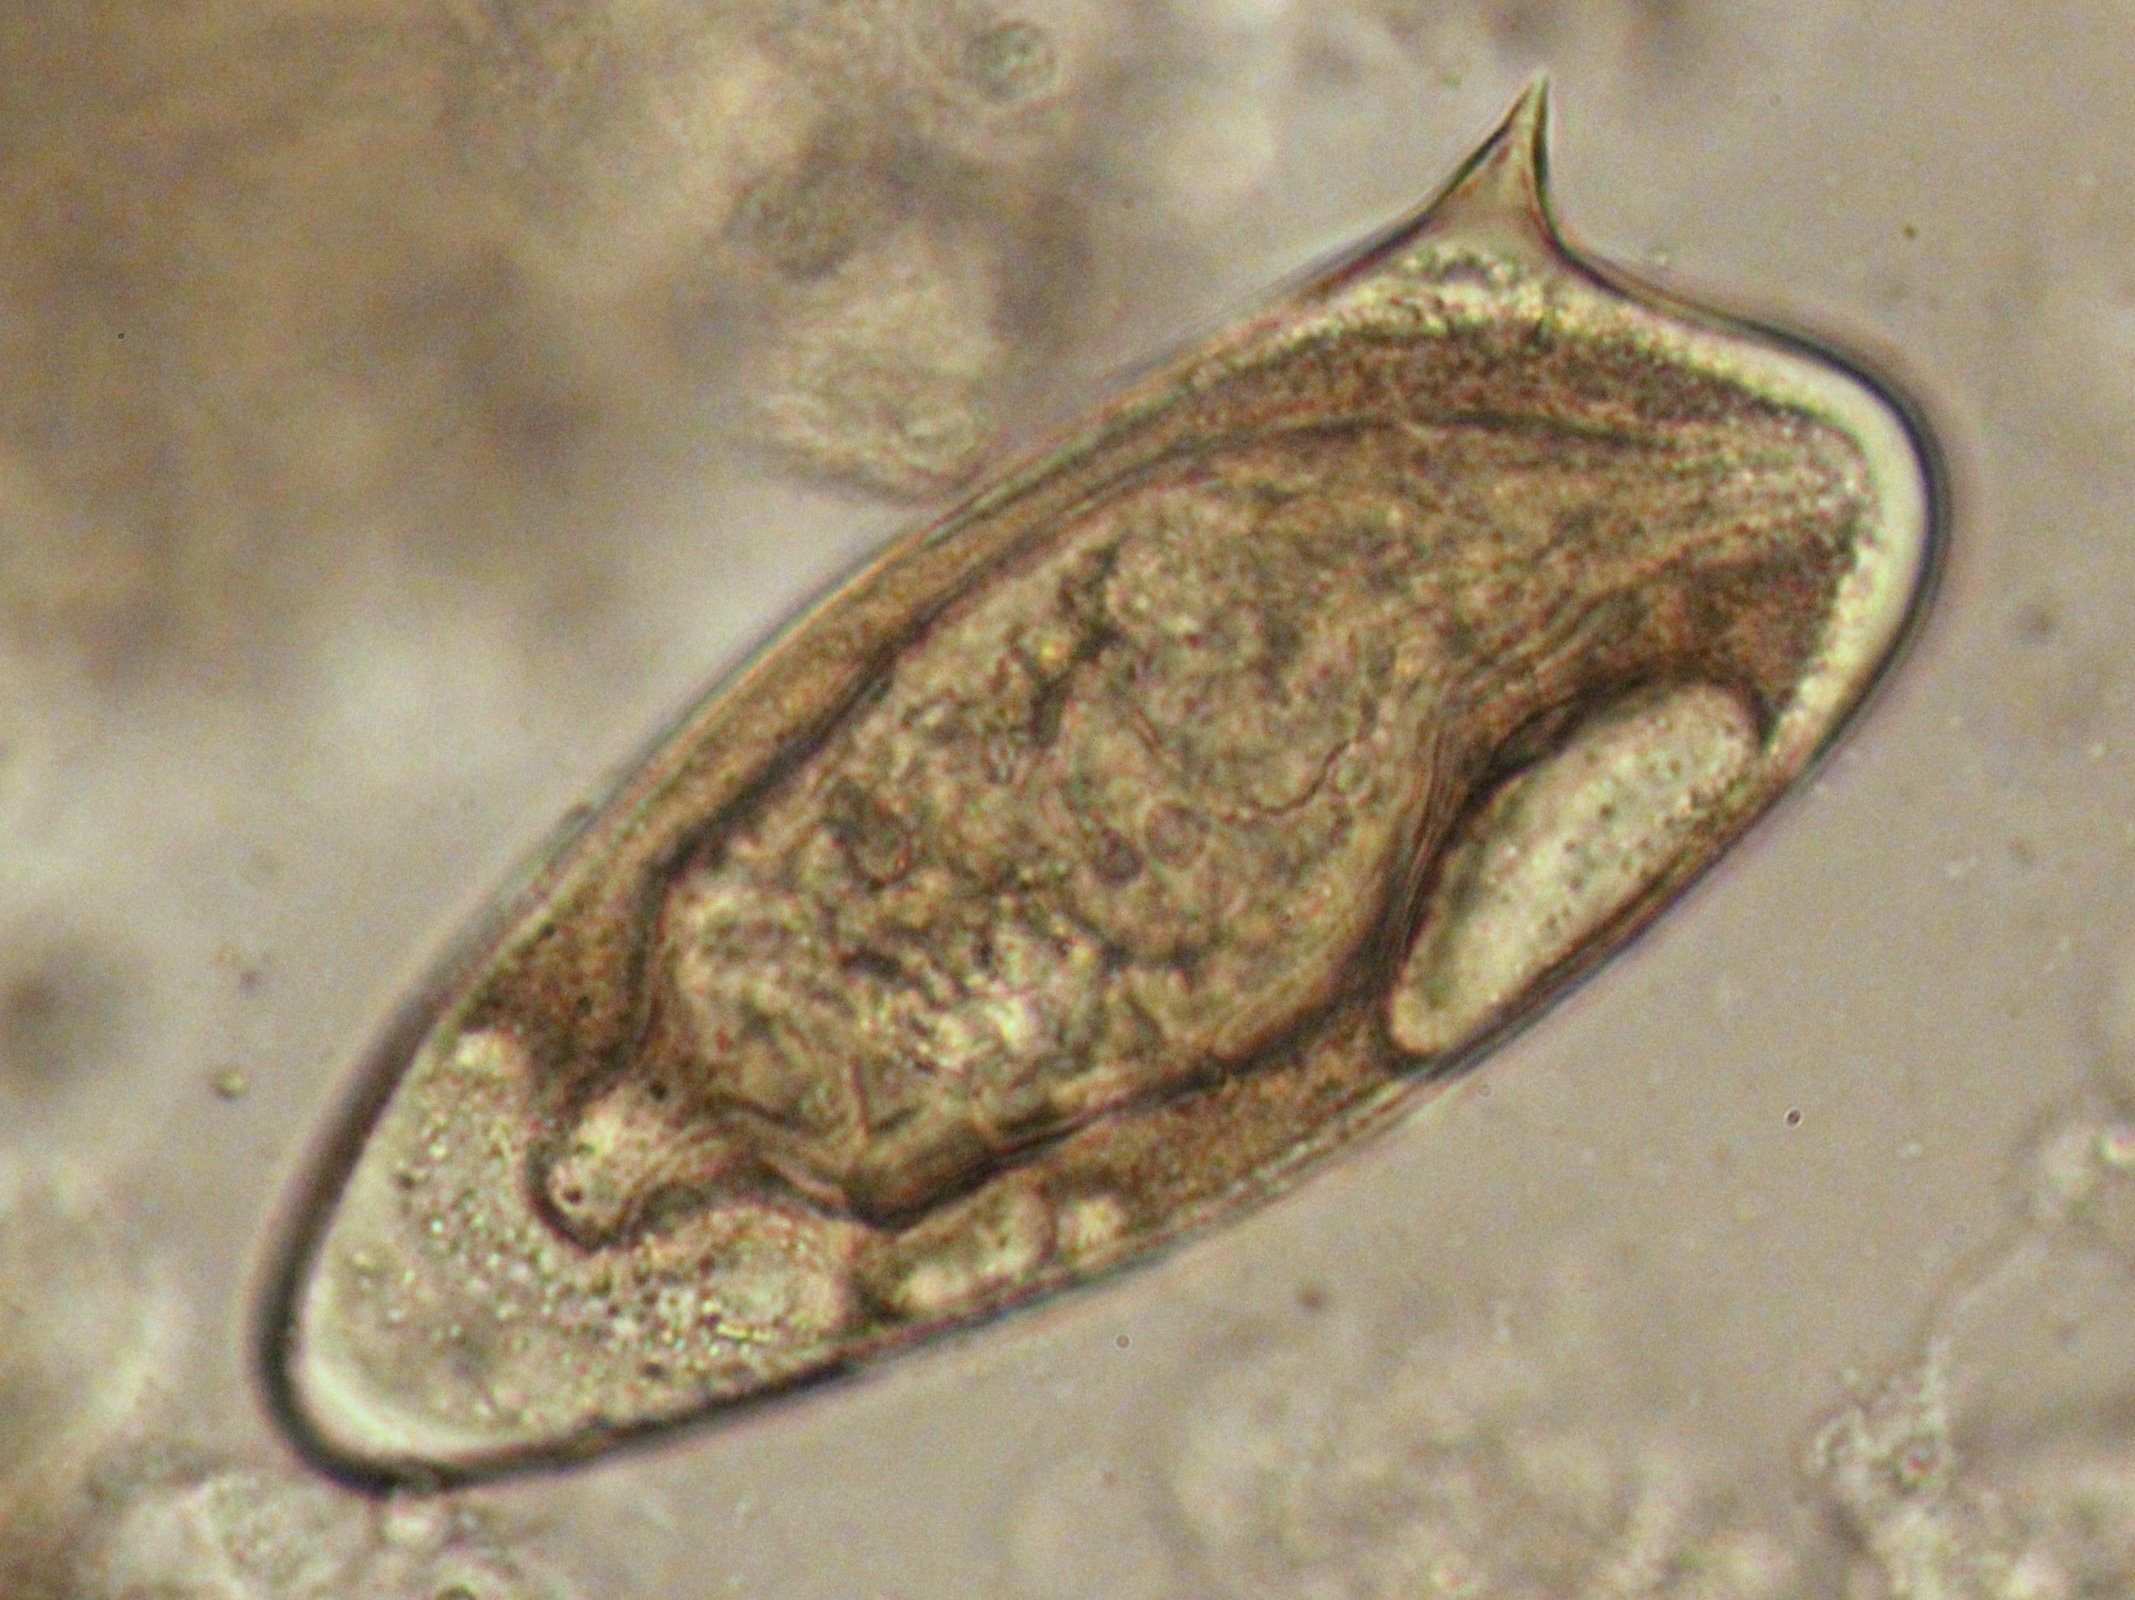

In [ ]:
PIL.Image.open(str(s_mansoni[1]))

**Load using keras.preprocessing**




In [ ]:
batch_size = 32
img_height = IMG_SIZE
img_width = IMG_SIZE

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  # image_size=(img_height, img_width),
  batch_size=batch_size)

Found 196 files belonging to 2 classes.
Using 157 files for training.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Fasciola', 'S.Mansoni']


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  # image_size=(None, None),
  batch_size=batch_size)

Found 196 files belonging to 2 classes.
Using 39 files for validation.


In [ ]:
train_ds.take(2)

<TakeDataset shapes: ((None, 256, 256, 3), (None,)), types: (tf.float32, tf.int32)>

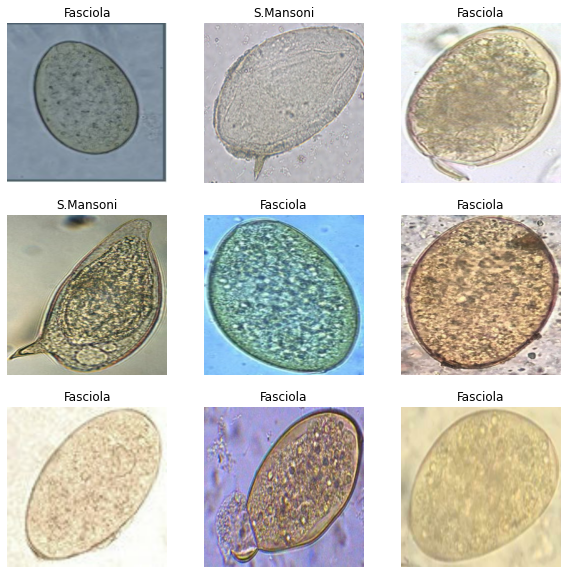

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 256, 256, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)


In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.00015767416 0.99433374


In [ ]:
num_classes = 2

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  # tfa.layers.SpatialPyramidPooling2D ([1,9,25]),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_2 (Rescaling)      (None, 256, 256, 3)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 256, 256, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 128, 128, 16)      0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 128, 128, 32)      4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 64, 64, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 64, 64, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 32, 32, 64)       

In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
5/5 [==============================] - 21s 5s/step - loss: 6.5182 - accuracy: 0.5811 - val_loss: 0.8801 - val_accuracy: 0.2432
Epoch 2/10
5/5 [==============================] - 13s 3s/step - loss: 0.7139 - accuracy: 0.6284 - val_loss: 0.5692 - val_accuracy: 0.7568
Epoch 3/10
5/5 [==============================] - 13s 3s/step - loss: 0.5807 - accuracy: 0.7095 - val_loss: 0.5723 - val_accuracy: 0.7568
Epoch 4/10
5/5 [==============================] - 13s 3s/step - loss: 0.5413 - accuracy: 0.7095 - val_loss: 0.5735 - val_accuracy: 0.7568
Epoch 5/10
5/5 [==============================] - 13s 3s/step - loss: 0.4990 - accuracy: 0.7095 - val_loss: 0.5604 - val_accuracy: 0.7297
Epoch 6/10
5/5 [==============================] - 13s 3s/step - loss: 0.4462 - accuracy: 0.7365 - val_loss: 0.5982 - val_accuracy: 0.6216
Epoch 7/10
5/5 [==============================] - 13s 3s/step - loss: 0.4397 - accuracy: 0.7365 - val_loss: 0.5643 - val_accuracy: 0.7297
Epoch 8/10
5/5 [==================

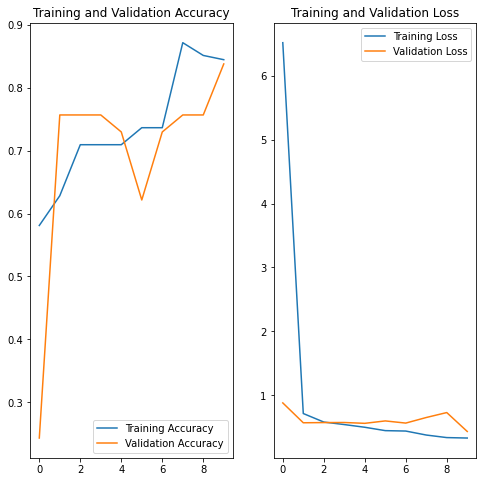

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Data Augmentation

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

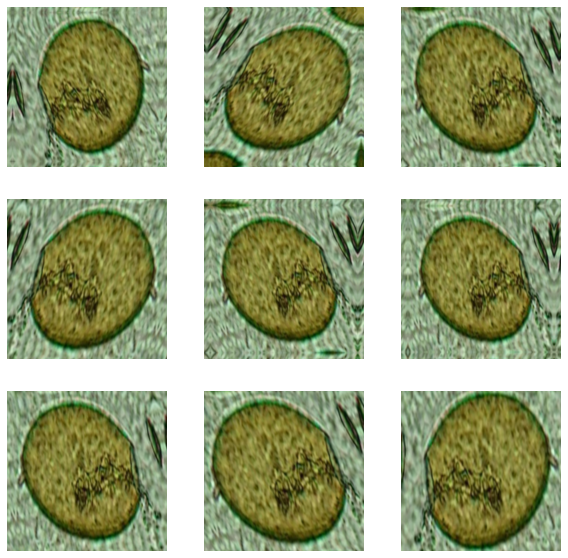

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
model_with_dropout = Sequential([
  data_augmentation,
  layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model_with_dropout.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model_with_dropout.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_2 (Sequential)    (None, 256, 256, 3)       0         
_________________________________________________________________
rescaling_4 (Rescaling)      (None, 256, 256, 3)       0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 256, 256, 16)      448       
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 128, 128, 16)      0         
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 128, 128, 32)      4640      
_________________________________________________________________
max_pooling2d_10 (MaxPooling (None, 64, 64, 32)        0         
_________________________________________________________________
conv2d_11 (Conv2D)           (None, 64, 64, 64)       

In [ ]:
epochs = 32
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/32
5/5 [==============================] - 15s 3s/step - loss: 0.2924 - accuracy: 0.8446 - val_loss: 0.5052 - val_accuracy: 0.8378
Epoch 2/32
5/5 [==============================] - 15s 3s/step - loss: 0.2952 - accuracy: 0.8581 - val_loss: 0.4430 - val_accuracy: 0.8649
Epoch 3/32
5/5 [==============================] - 15s 3s/step - loss: 0.2548 - accuracy: 0.9054 - val_loss: 0.4857 - val_accuracy: 0.8649
Epoch 4/32
5/5 [==============================] - 15s 3s/step - loss: 0.2585 - accuracy: 0.8986 - val_loss: 0.7614 - val_accuracy: 0.8108
Epoch 5/32
5/5 [==============================] - 15s 3s/step - loss: 0.3666 - accuracy: 0.8176 - val_loss: 0.4272 - val_accuracy: 0.8108
Epoch 6/32
5/5 [==============================] - 15s 3s/step - loss: 0.3245 - accuracy: 0.8514 - val_loss: 0.4423 - val_accuracy: 0.8108
Epoch 7/32
5/5 [==============================] - 15s 3s/step - loss: 0.2863 - accuracy: 0.8649 - val_loss: 0.5451 - val_accuracy: 0.8378
Epoch 8/32
5/5 [==================

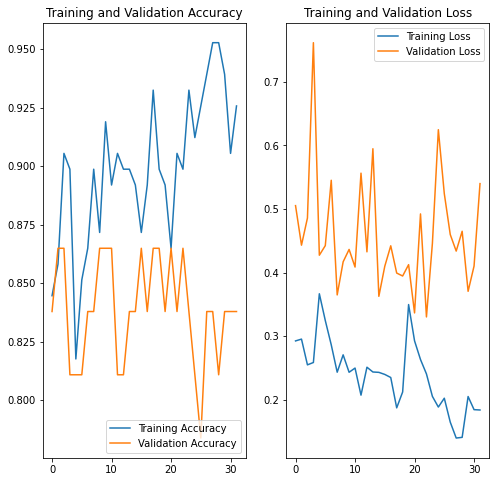

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Using Padded Images

***Test with Padded Images***

In [ ]:
data_p_dir = '/content/gdrive/MyDrive/HealthAI/Colabs/Baseline_Padded'
data_p_dir = pathlib.Path(data_p_dir)

In [ ]:
image_count = len(list(data_p_dir.glob('*/*')))
print(image_count)

197


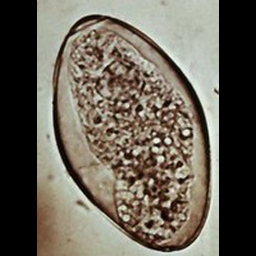

In [ ]:
fasciola = list(data_p_dir.glob('Fasciola/*'))
PIL.Image.open(str(fasciola[0]))

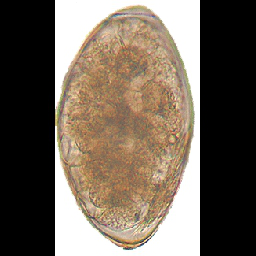

In [ ]:
PIL.Image.open(str(fasciola[1]))

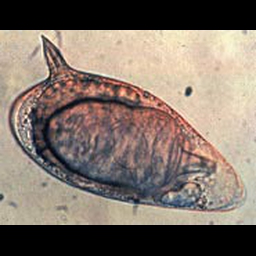

In [ ]:
s_mansoni = list(data_p_dir.glob('S.Mansoni/*'))
PIL.Image.open(str(s_mansoni[0]))

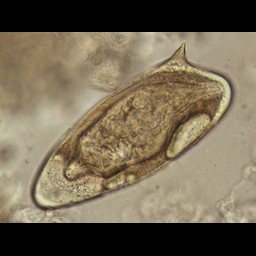

In [ ]:

PIL.Image.open(str(s_mansoni[1]))

In [ ]:
train_p_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_p_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  # image_size=(img_height, img_width),
  batch_size=batch_size)

Found 197 files belonging to 2 classes.
Using 158 files for training.


In [ ]:
val_p_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_p_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  # image_size=(None, None),
  batch_size=batch_size)

Found 197 files belonging to 2 classes.
Using 39 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Fasciola', 'S.Mansoni']


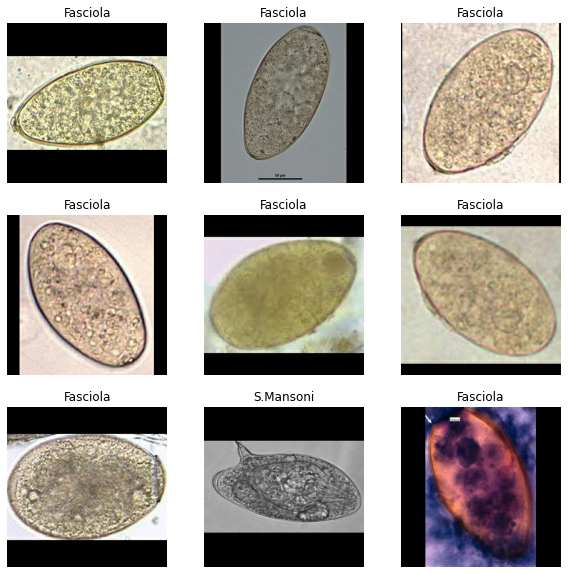

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_p_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_p_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 256, 256, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_p_ds = train_p_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_p_ds = val_p_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

In [ ]:
normalized_p_ds = train_p_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_p_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [ ]:
epochs=10
history_p = model.fit(
  train_p_ds,
  validation_data=val_p_ds,
  epochs=epochs
)

Epoch 1/10
5/5 [==============================] - 11s 2s/step - loss: 1.9282 - accuracy: 0.6203 - val_loss: 1.1271 - val_accuracy: 0.2308
Epoch 2/10
5/5 [==============================] - 10s 2s/step - loss: 0.7038 - accuracy: 0.5759 - val_loss: 0.5857 - val_accuracy: 0.7692
Epoch 3/10
5/5 [==============================] - 10s 2s/step - loss: 0.5314 - accuracy: 0.7342 - val_loss: 0.6135 - val_accuracy: 0.6667
Epoch 4/10
5/5 [==============================] - 10s 2s/step - loss: 0.5226 - accuracy: 0.7658 - val_loss: 0.7076 - val_accuracy: 0.7949
Epoch 5/10
5/5 [==============================] - 10s 2s/step - loss: 0.4827 - accuracy: 0.7595 - val_loss: 0.6386 - val_accuracy: 0.7692
Epoch 6/10
5/5 [==============================] - 10s 2s/step - loss: 0.4501 - accuracy: 0.8038 - val_loss: 0.6424 - val_accuracy: 0.7436
Epoch 7/10
5/5 [==============================] - 10s 2s/step - loss: 0.4128 - accuracy: 0.8418 - val_loss: 0.7426 - val_accuracy: 0.7949
Epoch 8/10
5/5 [==================

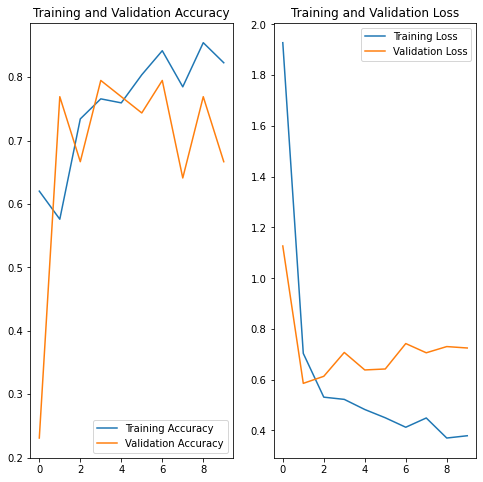

In [ ]:
acc = history_p.history['accuracy']
val_acc = history_p.history['val_accuracy']

loss = history_p.history['loss']
val_loss = history_p.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

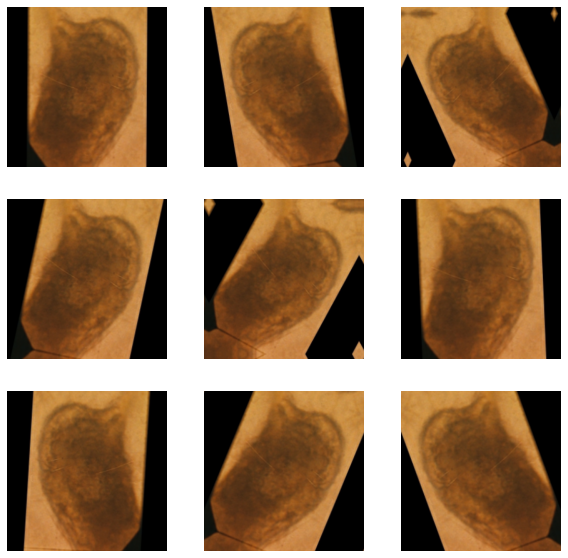

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_p_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
epochs = 40
history_p_with_do = model_with_dropout.fit(
  train_p_ds,
  validation_data=val_p_ds,
  epochs=epochs
)

Epoch 1/40
5/5 [==============================] - 11s 2s/step - loss: 0.3537 - accuracy: 0.8101 - val_loss: 0.6298 - val_accuracy: 0.7692
Epoch 2/40
5/5 [==============================] - 11s 2s/step - loss: 0.3675 - accuracy: 0.8228 - val_loss: 0.9025 - val_accuracy: 0.7436
Epoch 3/40
5/5 [==============================] - 11s 2s/step - loss: 0.4232 - accuracy: 0.8165 - val_loss: 0.7330 - val_accuracy: 0.7179
Epoch 4/40
5/5 [==============================] - 11s 2s/step - loss: 0.3825 - accuracy: 0.8544 - val_loss: 0.6940 - val_accuracy: 0.7179
Epoch 5/40
5/5 [==============================] - 11s 2s/step - loss: 0.4016 - accuracy: 0.7975 - val_loss: 0.6258 - val_accuracy: 0.7692
Epoch 6/40
5/5 [==============================] - 11s 2s/step - loss: 0.3862 - accuracy: 0.8418 - val_loss: 0.6531 - val_accuracy: 0.7692
Epoch 7/40
5/5 [==============================] - 11s 2s/step - loss: 0.2996 - accuracy: 0.8861 - val_loss: 0.7978 - val_accuracy: 0.7692
Epoch 8/40
5/5 [==================

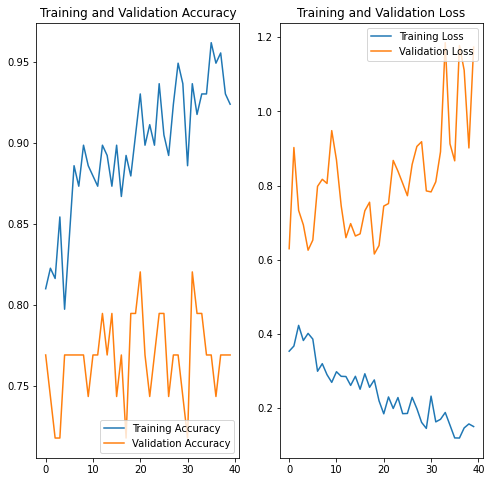

In [ ]:
acc = history_p_with_do.history['accuracy']
val_acc = history_p_with_do.history['val_accuracy']

loss = history_p_with_do.history['loss']
val_loss = history_p_with_do.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()